# Experiment 01: PDF Loader Comparison

## Objective

The objective of this experiment is to compare two popular PDF loading libraries:

- PyMuPDF
- pdfplumber

The comparison is performed on the same PDF document (SBP-Act.pdf) to determine which library is more suitable for a production-level Retrieval-Augmented Generation (RAG) pipeline.

The comparison is based on:

- Extraction Time
- Number of Pages
- Characters Extracted
- Words Extracted
- Text Quality

In [1]:
import fitz
import pdfplumber
import time
import pandas as pd

# Dataset

Document Used:

SBP-Act.pdf

This document contains the State Bank of Pakistan Act and represents a real-world regulatory document that will be used throughout the AI Compliance Assistant project.
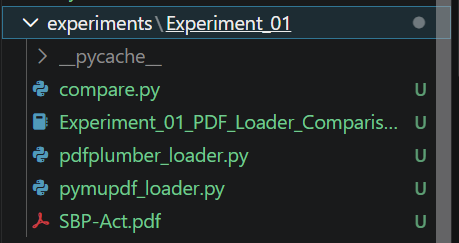

# PyMuPDF Implementation

PyMuPDF is a high-performance PDF processing library.

Advantages

- Fast
- Lightweight
- Excellent for text extraction
- Production Ready

In [2]:
def extract_with_pymupdf(pdf_path):
    start_time = time.perf_counter()

    document = fitz.open(pdf_path)
    extracted_text = ""

    for page in document:
        extracted_text += page.get_text()

    end_time = time.perf_counter()

    result = {
        "loader": "PyMuPDF",
        "pages": len(document),
        "characters": len(extracted_text),
        "words": len(extracted_text.split()),
        "time": round(end_time - start_time, 4),
        "text": extracted_text,
    }

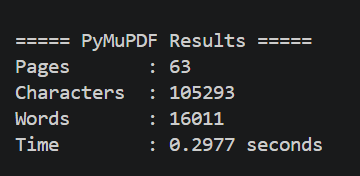

# pdfplumber Implementation

pdfplumber is primarily designed for extracting structured content from PDFs.

Advantages

- Better table extraction
- Better layout preservation

In [3]:
def extract_with_pdfplumber(pdf_path):
    """
    Extract text from a PDF using pdfplumber.
    Returns extraction statistics.
    """

    start_time = time.perf_counter()

    extracted_text = ""

    with pdfplumber.open(pdf_path) as pdf:

        pages = len(pdf.pages)

        for page in pdf.pages:
            page_text = page.extract_text()

            if page_text:
                extracted_text += page_text

    end_time = time.perf_counter()

    return {
        "loader": "pdfplumber",
        "pages": pages,
        "characters": len(extracted_text),
        "words": len(extracted_text.split()),
        "time": round(end_time - start_time, 4),
        "text": extracted_text,
    }



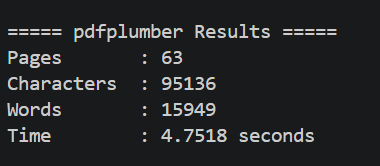

# Comparison

Both loaders were evaluated using the same PDF document.

In [4]:
comparison = pd.DataFrame({
    "Metric":[
        "Pages",
        "Characters",
        "Words",
        "Time (seconds)"
    ],
    "PyMuPDF":[
        63,
        105293,
        16011,
        0.2977
    ],
    "pdfplumber":[
        63,
        95136,
        15949,
        4.7518
    ]
})

comparison

,Metric,PyMuPDF,pdfplumber
0,Pages,63.0000,63.0000
1,Characters,105293.0000,95136.0000
2,Words,16011.0000,15949.0000
3,Time (seconds),0.2977,4.7518


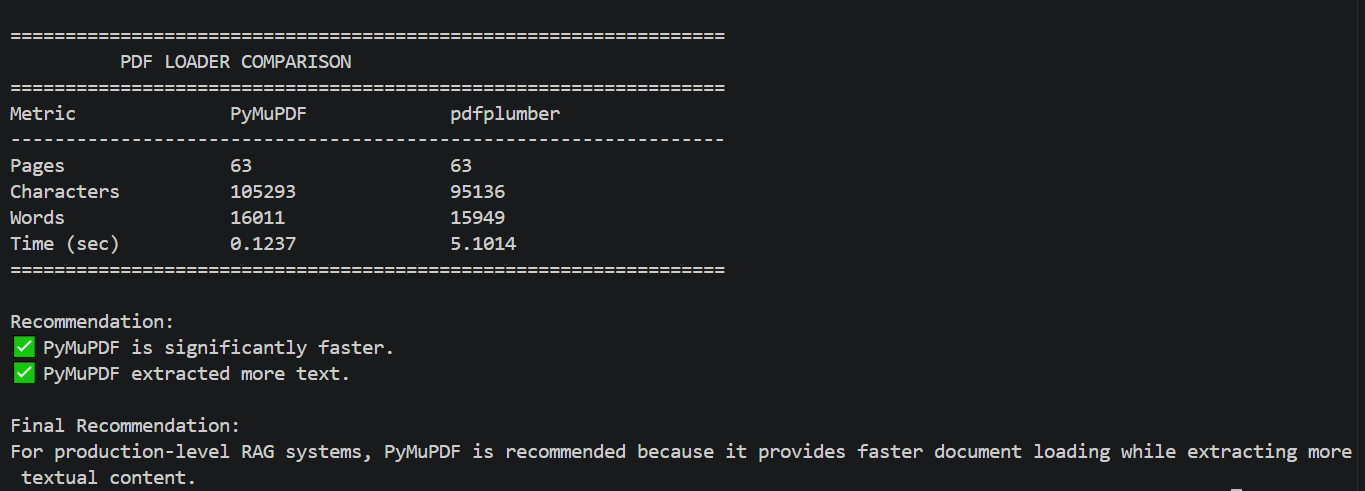

# Result Analysis

Observations

- Both libraries processed all 63 pages.
- PyMuPDF extracted more textual content.
- PyMuPDF completed extraction significantly faster.
- pdfplumber preserved formatting better but required considerably more processing time.

# Conclusion

Based on the experimental results, PyMuPDF is the preferred choice for the AI Compliance Assistant.

Reasons:

- Faster execution
- Higher text extraction
- Lower processing overhead
- Better suited for production-scale RAG systems

pdfplumber remains useful when accurate table extraction or document layout preservation is required.